# 05 Backpropagation Detailed

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- See how gradients flow backward through the network (backpropagation)
- Use PyTorch autograd (`loss.backward()`) to compute gradients for a small model
- Understand why we use backprop instead of guessing weights
- Read a real gradient honestly: pixels that never vary get a gradient of exactly zero, and one real feature only takes a price model so far

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 2, lesson 04 "Programming Backpropagation in Neural Networks" — you derived and coded the chain rule by hand there; here `loss.backward()` does it and your job is to check that it agrees.

**Used later in:** Course 09 (AIAT 123) — Unit 3, lesson 01 "DQN Implementation" — the same autograd machinery, training an agent.

---

## 🌍 Real life

**Where is this used?** Every time you train a neural network (digit recognition, image classification, NLP), the **optimizer** uses **gradients** from backpropagation to update the weights.

**In this notebook we use** **backpropagation** (via PyTorch autograd) to **compute gradients of the loss with respect to the weights**. We use it **instead of** guessing or randomly changing weights **because** gradients tell us **in which direction** to change each weight to reduce the loss.

**📌 Covers slide(s):** **23** — Keras, training flow (how gradients and optimizer work). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below. Requires PyTorch and scikit-learn (which supplies the real handwritten digits and the real house-price data — no downloads).


## Theory (short)

- **Forward pass:** input → layers → output → loss.
- **Backpropagation:** we compute how much each weight contributed to the loss (the **gradient** of loss w.r.t. that weight) using the **chain rule**.
- **Gradients flow backward:** from output/loss back through each layer to the weights.
- **Optimizer** (e.g. Adam) uses these gradients to update weights: `new_weight = old_weight - learning_rate * gradient`.
- **Data flow:** forward: input → layers → loss. Backward: loss → gradients → update weights.

### Key math (required)

- **Chain rule:** If \(L\) is the loss and \(w\) is a weight, \(\frac{\partial L}{\partial w} = \frac{\partial L}{\partial a}\cdot\frac{\partial a}{\partial z}\cdot\frac{\partial z}{\partial w}\) where \(a\) is the layer output and \(z\) is the pre-activation. Backprop computes these derivatives layer by layer from output to input.
- **Gradient update:** \(w_{\text{new}} = w_{\text{old}} - \eta\,\frac{\partial L}{\partial w}\) with learning rate \(\eta\).
- For full derivation (e.g. matrix form, multi-layer), see the lecture slides or Goodfellow et al., *Deep Learning*, Ch. 6.

**The steps below put this theory into code.**

💡 **If this is unclear:** Run the next few cells and look at the printed **loss** and **gradient shapes**; the code is doing the chain rule. The "loss before vs after one update" cell shows that the optimizer moved the weights in the right direction. If still stuck, tell your instructor: "I didn't get the backprop / gradient part in notebook 05" so they can go over that cell with you.


## 📥 Inputs & 📤 Outputs

**Inputs:** PyTorch, NumPy, scikit-learn. We take a **real batch of 8 handwritten digits** from the `load_digits` dataset that ships inside scikit-learn (no download), so the loss and the gradients are computed on real pixels and real labels.

**Dataset (real):** UCI *Optical Recognition of Handwritten Digits* — 1,797 images, 8x8 pixels, values 0-16, bundled with scikit-learn. It is MNIST's small cousin: same task (classify 0-9), 64 pixels instead of 784.

**Outputs:** Loss value (one number), the number of parameter tensors with gradients and a sample of real gradient values, then "loss before update" and "loss after one update" (loss should go down).

In [1]:
# Step 1: Imports — PyTorch autograd for backpropagation
# torch.nn builds layers, torch.optim applies updates, and autograd computes the gradients for us.
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
# scikit-learn ships a real handwritten-digit dataset inside the library, so no download is needed.
from sklearn.datasets import load_digits
print(f'PyTorch {torch.__version__}')
print('✅ Imports OK.')

PyTorch 2.13.0
✅ Imports OK.


Dataset: 1797 real 8x8 images, pixel values 0-16
Input batch shape: torch.Size([8, 64])
True labels in this batch: [0, 1, 2, 3, 4, 5, 6, 7]


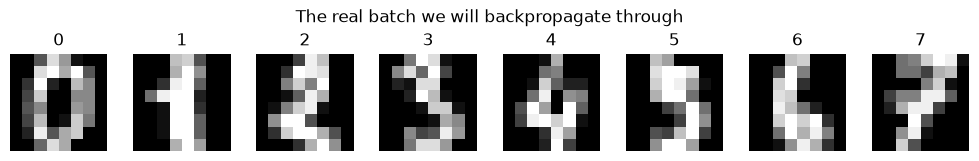

In [2]:
# Step 2: Load a REAL batch of handwritten digits (scikit-learn's bundled UCI digits)
# WHY real data: a gradient only means something if the label it is pushing towards is real.
digits = load_digits()                       # 1797 images, 8x8 pixels, values 0-16
X = digits.data.astype(np.float32) / 16.0    # scale pixels to 0-1, as models expect
y = digits.target                            # the true digit written in each image

# Take the first 8 images as one small batch we can inspect by eye.
x_flat  = torch.tensor(X[:8])                       # 8 images, 64 pixels each (already flattened)
y_batch = torch.tensor(y[:8], dtype=torch.long)     # their REAL labels

print('Dataset:', digits.images.shape[0], 'real 8x8 images, pixel values 0-16')
print('Input batch shape:', x_flat.shape)
print('True labels in this batch:', y_batch.tolist())

# Show the 8 real digits so you can check the labels yourself.
fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
for ax, image, label in zip(axes, digits.images[:8], y[:8]):
    ax.imshow(image, cmap='gray'); ax.set_title(str(label)); ax.axis('off')
plt.suptitle('The real batch we will backpropagate through'); plt.tight_layout(); plt.show()

In [3]:
# Step 3: Build a tiny model (one hidden layer) so gradients are easy to inspect
# 64 pixels -> 16 hidden ReLU units -> 10 class scores; small enough to inspect every gradient.
# torch.manual_seed fixes the RANDOM WEIGHT INITIALISATION — random weights are part of the lesson,
# random *data* is not, which is why the batch above is real.
torch.manual_seed(0)
model = nn.Sequential(
    nn.Linear(64, 16),
    nn.ReLU(),
    nn.Linear(16, 10),
)
print(model)

Sequential(
  (0): Linear(in_features=64, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=10, bias=True)
)


In [4]:
# Step 4: Forward pass + compute loss; PyTorch builds the computational graph automatically.
# Calling .backward() computes all gradients (equivalent to GradientTape in TF).
criterion = nn.CrossEntropyLoss()
logits = model(x_flat)              # forward pass
loss   = criterion(logits, y_batch)  # compute loss
loss.backward()                      # backpropagation — fills .grad for all parameters
print(f'Loss before update: {loss.item():.4f}')
print('Gradients computed for', sum(1 for p in model.parameters() if p.grad is not None), 'parameter tensors')

Loss before update: 2.2771
Gradients computed for 4 parameter tensors


In [5]:
# (Next: Step 5 — look at actual gradient values.)

In [6]:
# Step 5: Inspect real gradient values from the first linear layer
W1_grad = model[0].weight.grad          # shape (16 hidden units, 64 pixels)
print('Gradient tensor for layer 1 weights:', tuple(W1_grad.shape))

# (a) The first 10 weights of the first hidden neuron:
print('\nFirst 10 gradients of hidden neuron 0:')
print(W1_grad[0, :10].numpy().round(5))

# Why are they exactly 0.0? Because dL/dw = (upstream gradient) * x, and those first pixels
# sit in the border of the image: in these 8 real digits they are ALWAYS dark (x = 0).
# A pixel that never lights up can never change the loss, so its weight gets no gradient.
never_lit = int((X[:8].max(axis=0) == 0).sum())
zero_cols = int((W1_grad.abs().sum(0) == 0).sum())
print(f'Pixels that are always 0 in this batch: {never_lit} of 64')
print(f'Pixel columns whose gradient is exactly 0: {zero_cols} of 64  -> the same pixels.')

# (b) The pixels that DO carry signal — the largest gradients in the layer:
top = torch.topk(W1_grad.abs().flatten(), 5).values
print('\n5 largest |gradient| values in layer 1:', top.numpy().round(5))
print('Non-zero values on the lit pixels confirm backprop is working — the network now knows',
      'which pixel weights to change, and in which direction.')

Gradient tensor for layer 1 weights: (16, 64)

First 10 gradients of hidden neuron 0:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Pixels that are always 0 in this batch: 17 of 64
Pixel columns whose gradient is exactly 0: 17 of 64  -> the same pixels.

5 largest |gradient| values in layer 1: [0.05273 0.05052 0.04916 0.04907 0.04902]
Non-zero values on the lit pixels confirm backprop is working — the network now knows which pixel weights to change, and in which direction.


In [7]:
# Step 6: One manual update step — loss should decrease
optimizer = optim.Adam(model.parameters(), lr=1e-3)
optimizer.step()     # apply the gradients computed in Step 4
optimizer.zero_grad()

# Recompute loss after update to confirm it went down
with torch.no_grad():
    loss_after = criterion(model(x_flat), y_batch)
print(f'Loss before update: {loss.item():.4f}')
print(f'Loss after  update: {loss_after.item():.4f}')
print('Loss decreased:', loss_after.item() < loss.item())

Loss before update: 2.2771
Loss after  update: 2.2682
Loss decreased: True


## 🌍 Real-World Worked Example — House Prices (Manual Backprop on Real Data)

**Industry context:** Property platforms estimate a home's value from features such as income of the
neighbourhood, house age and number of rooms, and they train those regressors with gradient descent.

Below we implement a 1-hidden-layer network **with manual backpropagation** — every derivative written
out by hand, no autograd — on the **California Housing** dataset (20,640 block groups from the 1990 US
Census, bundled with scikit-learn). We predict the **median house value of a block group** from a single
real feature: the **median income** of that block group.

**Read the result honestly:** real prices are *not* a straight line plus a little noise. Watch how much
of the variance one real feature actually explains, and look for the horizontal band of points at
$500,001 — the Census capped every value there, and the data can never go above it.

Real dataset: California Housing — 1000 of 20640 block groups (random_state=42)
Feature: MedInc, range 0.68-15.00 ($10k)
Target : median house value, range 0.30-5.00 ($100k)
Values capped at $500,001 by the Census: 4.8% of this sample

MSE (standardised): 1.0257 -> 0.5194 after 500 epochs
R² on real prices : 0.481  (a plain straight line gets 0.474)
Typical error     : $83,873 per block group


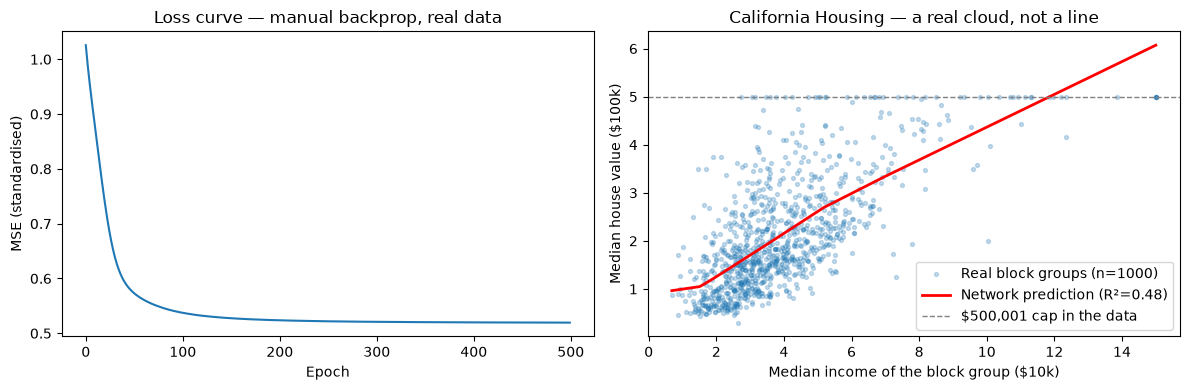

In [8]:
# WHAT: manual backpropagation (chain rule by hand) on a REAL regression dataset.
# WHY: the same six derivative lines that autograd runs for you above — but written out, on real prices.
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression

# ── Real data: California Housing (1990 US Census), bundled with scikit-learn ───────────────
housing = fetch_california_housing()
sampler = np.random.RandomState(42)                    # sampling only — the DATA is real
idx = sampler.choice(len(housing.data), size=1000, replace=False)
X = housing.data[idx][:, [0]].astype(np.float32)       # MedInc: median income, in $10,000s
y = housing.target[idx].reshape(-1, 1).astype(np.float32)  # median house value, in $100,000s

print(f"Real dataset: California Housing — {len(X)} of {len(housing.data)} block groups (random_state=42)")
print(f"Feature: MedInc, range {X.min():.2f}-{X.max():.2f} ($10k)")
print(f"Target : median house value, range {y.min():.2f}-{y.max():.2f} ($100k)")
print(f"Values capped at $500,001 by the Census: {(y >= 5.0).mean()*100:.1f}% of this sample")

# Standardise both (gradient descent behaves badly on raw scales).
X_n = (X - X.mean()) / X.std()
y_n = (y - y.mean()) / y.std()

# ── Manual 1-hidden-layer network ──────────────────────────────────────────────────────────
def relu(z): return np.maximum(0, z)
def relu_d(z): return (z > 0).astype(float)

init = np.random.RandomState(0)          # random WEIGHT INIT — this randomness is the lesson
W1 = init.randn(1, 16) * 0.1;  b1 = np.zeros((1, 16))
W2 = init.randn(16, 1) * 0.1;  b2 = np.zeros((1, 1))
lr = 0.05;  losses = [];  n = len(X_n)

for _ in range(500):
    # Forward
    z1 = X_n @ W1 + b1          # (n, 16)
    a1 = relu(z1)
    z2 = a1 @ W2 + b2            # (n, 1)
    loss = ((z2 - y_n)**2).mean()
    losses.append(loss)

    # ── Backpropagation (chain rule, step by step) ─────────────────────────
    dL_dz2 = 2*(z2 - y_n) / n
    dL_dW2 = a1.T @ dL_dz2
    dL_db2 = dL_dz2.sum(0, keepdims=True)
    dL_da1 = dL_dz2 @ W2.T
    dL_dz1 = dL_da1 * relu_d(z1)
    dL_dW1 = X_n.T @ dL_dz1
    dL_db1 = dL_dz1.sum(0, keepdims=True)

    # Gradient descent step
    W2 -= lr * dL_dW2;  b2 -= lr * dL_db2
    W1 -= lr * dL_dW1;  b1 -= lr * dL_db1

# ── Score it on the real price scale, and against a plain straight line ────────────────────
pred = (relu(X_n @ W1 + b1) @ W2 + b2) * y.std() + y.mean()
r2   = 1 - ((pred - y)**2).sum() / ((y - y.mean())**2).sum()
rmse = float(np.sqrt(((pred - y)**2).mean()))
ols_r2 = LinearRegression().fit(X, y).score(X, y)     # honest baseline: one straight line

print(f"\nMSE (standardised): {losses[0]:.4f} -> {losses[-1]:.4f} after 500 epochs")
print(f"R² on real prices : {r2:.3f}  (a plain straight line gets {ols_r2:.3f})")
print(f"Typical error     : ${rmse*100_000:,.0f} per block group")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses); plt.title("Loss curve — manual backprop, real data")
plt.xlabel("Epoch"); plt.ylabel("MSE (standardised)")
plt.subplot(1, 2, 2)
order = X[:, 0].argsort()
plt.scatter(X, y, s=8, alpha=0.25, label=f"Real block groups (n={len(X)})")
plt.plot(X[order], pred[order], 'r-', lw=2, label=f"Network prediction (R²={r2:.2f})")
plt.axhline(5.0, ls='--', c='gray', lw=1, label="$500,001 cap in the data")
plt.xlabel("Median income of the block group ($10k)"); plt.ylabel("Median house value ($100k)")
plt.legend(); plt.title("California Housing — a real cloud, not a line")
plt.tight_layout(); plt.show()

---

## 🧩 Mini-exercise

**Try it:** In a new code cell, run another forward pass and `loss.backward()` (Step 6 cleared the old gradients with `optimizer.zero_grad()`), then print the first layer's weight gradient and its shape: `model[0].weight.grad` / `model[0].weight.grad.shape`. Finally call `optimizer.step()` and print the loss again—does it decrease further?

**Then:** change `x_flat`/`y_batch` in Step 2 to a *different* slice of the real digits (e.g. `X[100:108]`, `y[100:108]`) and re-run Steps 3-5. Do the same border pixels still get a zero gradient?

---

## ✅ Summary

**What you did:**
- Loaded a **real batch of 8 handwritten digits** (scikit-learn's bundled UCI digits) and built a tiny one-hidden-layer model.
- Used **PyTorch autograd** (`loss.backward()`) to run a forward pass and compute **gradients** (backpropagation) on those real pixels and real labels.
- Saw a real-data effect: the 17 border pixels that are never lit in this batch get a gradient of **exactly 0.0** — a weight can only learn from a pixel that varies.
- Checked one manual update step: the loss went **down** (2.2771 → 2.2682 after a single Adam step at lr=1e-3 — one step is a small nudge, not a fix).
- Repeated the whole thing **by hand** on real California Housing prices: 500 epochs of manual chain-rule updates reached **R² = 0.481**, barely above the **0.474** a single straight line achieves, with a typical error of about **$84,000**.

**Be honest about that last number:** one real feature (neighbourhood income) explains under half of what house prices do, and 4.8% of the targets are clipped at the $500,001 Census ceiling — which is why the model happily predicts *above* a value the data can never contain. Backprop optimises whatever loss you hand it; it cannot invent information the features do not carry.

**In real life you'd also:** train for many steps (a training loop does forward + backprop + update repeatedly) and use all 8 features, not one.

**The main idea:** Backpropagation gives us gradients of the loss w.r.t. each weight; the optimizer uses them to update weights so the loss goes down.

**Next:** `06_optimization_techniques` compares different optimizers (SGD, Adam, etc.) and how they use these gradients.

## 📚 References

1. Rumelhart, D. E., Hinton, G. E. & Williams, R. J. (1986). *Learning representations by back-propagating errors*. Nature 323, 533-536. https://doi.org/10.1038/323533a0
2. Baydin, A. G., Pearlmutter, B. A., Radul, A. A. & Siskind, J. M. (2018). *Automatic Differentiation in Machine Learning: a Survey*. JMLR 18(153). https://arxiv.org/abs/1502.05767
3. Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning* (ch. 6.5, Back-Propagation). MIT Press. https://www.deeplearningbook.org/

**Datasets used in this notebook**

4. Alpaydin, E. & Kaynak, C. (1998). *Optical Recognition of Handwritten Digits*. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits (bundled with scikit-learn as `load_digits`)
5. Pace, R. K. & Barry, R. (1997). *Sparse spatial autoregressions*. Statistics & Probability Letters 33(3), 291-297. https://doi.org/10.1016/S0167-7152(96)00140-X (the California Housing data, from the 1990 US Census; `fetch_california_housing`)

**Recent work (2024–2026)**

6. Zhao, J. et al. (2024). *GaLore: Memory-Efficient LLM Training by Gradient Low-Rank Projection*. ICML 2024. https://arxiv.org/abs/2403.03507 — in 2026 the binding cost of backpropagation is memory, not arithmetic. Projecting gradients into a low-rank subspace cut optimizer-state memory by up to 65.5% and put 7B-parameter pre-training on a single 24 GB consumer GPU.
7. Liu, J. et al. (2025). *Muon is Scalable for LLM Training*. arXiv. https://arxiv.org/abs/2502.16982 — what modern large-scale training does with the gradient matrices this notebook computes by hand.
